# Random Forest - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

Why does a crowd of noisy trees beat one careful tree? We DEMO the two
randomness injections (bootstrap rows, random feature splits) on real penguin
data and watch errors cancel.

## What you'll learn
- Bootstrap sampling: duplicates & out-of-bag rows, counted by hand
- Feature-subset randomness at every split
- Majority voting mechanics across trees
- Error-cancellation demo: single tree vs forest stability

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

y = pen["species"].values
X = pd.get_dummies(pen.drop(columns=["species", "island"]),
                   columns=["sex"], drop_first=True).values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.3,
                                          random_state=42, stratify=y)

## 1. Bootstrap by hand - duplicates and the out-of-bag 37%

In [2]:
n = len(X_tr)
rng = np.random.RandomState(0)
boot_idx = rng.randint(0, n, n)                 # sample n indices WITH replacement

unique_rows = len(set(boot_idx))
print(f"bootstrap sample of {n} rows used {unique_rows} unique rows")
print(f"left-out (out-of-bag) rows      : {n - unique_rows} "
      f"({(n-unique_rows)/n:.0%} - theory says ≈ 37%)")
print("→ each OOB row is unseen by THIS tree: free validation material")

bootstrap sample of 233 rows used 150 unique rows
left-out (out-of-bag) rows      : 83 (36% — theory says ≈ 37%)
→ each OOB row is unseen by THIS tree: free validation material


## 2. Feature-subset randomness at every split

Each split only CONSIDERS `max_features` (=√13≈4 here) randomly chosen
features - so no single dominant column clones itself into every tree.

In [3]:
n_feats = X.shape[1]
per_split = int(np.sqrt(n_feats))
print(f"{n_feats} total features → each split considers {per_split} random ones")

example_draws = [tuple(sorted(rng.choice(n_feats, per_split, replace=False)))
                 for _ in range(4)]
for i, d in enumerate(example_draws, 1):
    print(f"  split {i} candidate features: {d}")

5 total features → each split considers 2 random ones
  split 1 candidate features: (np.int32(2), np.int32(4))
  split 2 candidate features: (np.int32(0), np.int32(2))
  split 3 candidate features: (np.int32(2), np.int32(3))
  split 4 candidate features: (np.int32(1), np.int32(4))


## 3. The vote - three trees disagree, forest decides

In [4]:
votes = []
for seed in [7, 21, 99]:
    idx = rng.randint(0, n, n)                        # each tree: own bootstrap
    t = DecisionTreeClassifier(random_state=seed).fit(X_tr[idx], y_tr[idx])
    votes.append(t)
    q = X_te[0]
    print(f"tree(seed={seed}) predicts: {t.predict([q])[0]}")

rf_pred = max(set(v.predict([q])[0] for v in votes),
              key=[v.predict([q])[0] for v in votes].count)
print(f"\nmajority vote on this passenger: {rf_pred}")

tree(seed=7) predicts: Chinstrap
tree(seed=21) predicts: Chinstrap
tree(seed=99) predicts: Chinstrap

majority vote on this passenger: Chinstrap


## 4. Error cancellation - single trees wobble, the forest stands still

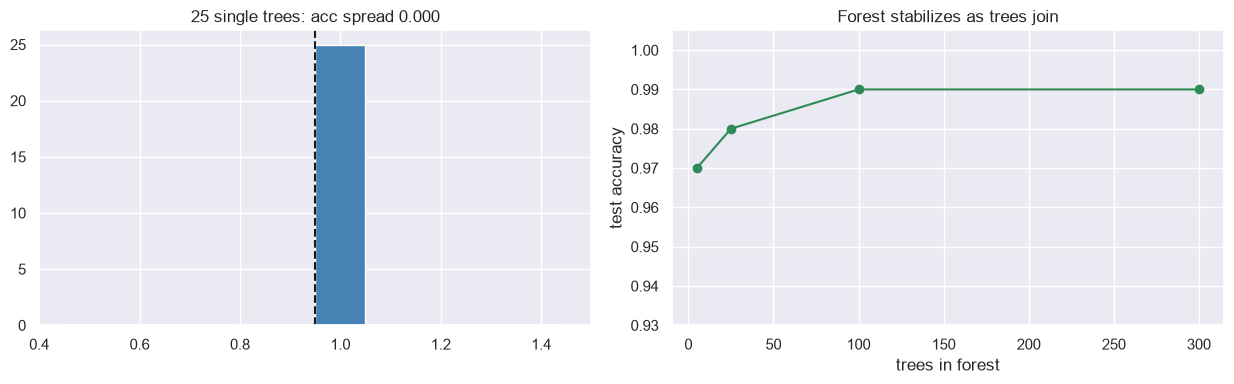

single-tree mean 0.9500 ± 0.0000
forest converges ABOVE the average single tree and barely varies.


In [5]:
single_accs = [DecisionTreeClassifier(random_state=s).fit(X_tr, y_tr) \
               .score(X_te, y_te) for s in range(25)]
forest_accs = [RandomForestClassifier(n_estimators=k, random_state=1) \
               .fit(X_tr, y_tr).score(X_te, y_te)
               for k in [5, 25, 100, 300]]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].hist(single_accs, bins=10, color="steelblue")
axes[0].axvline(np.mean(single_accs), c="k", ls="--")
axes[0].set_title(f"25 single trees: acc spread "
                  f"{np.std(single_accs):.3f}")
axes[1].plot([5, 25, 100, 300], forest_accs, "o-", color="seagreen")
axes[1].set_ylim(min(single_accs)-.02, 1.005)
axes[1].set_xlabel("trees in forest"); axes[1].set_ylabel("test accuracy")
axes[1].set_title("Forest stabilizes as trees join")
plt.tight_layout(); plt.show()

print(f"single-tree mean {np.mean(single_accs):.4f} ± {np.std(single_accs):.4f}")
print("forest converges ABOVE the average single tree and barely varies.")

## Summary & key takeaways

- Two randomness sources decorrelate trees: bootstrap ROWS + random FEATURE
  subsets per split.
- Averaging uncorrelated errors cuts variance without raising bias - the
  statistical engine of all bagging ensembles.
- OOB rows give every tree a private exam → `oob_score=True` = free CV.
- More trees never hurt accuracy; they only cost time/memory.